C:\Users\Madhu\AppData\Local\Temp\ipykernel_14656\2263105757.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='Set2', order=df['category'].value_counts().index)


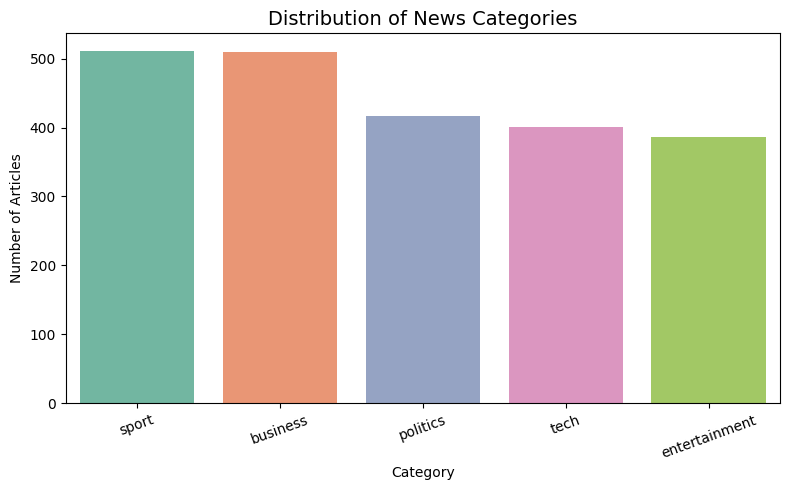

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim.models import Phrases, LdaModel
from gensim.models.phrases import Phraser
from gensim import corpora
from sklearn.manifold import TSNE

# Step 1: Load and clean data
df = pd.read_csv("bbc-text.csv")
df.dropna(subset=['text'], inplace=True)

# Plot count of each news category
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='category', palette='Set2', order=df['category'].value_counts().index)

plt.title("Distribution of News Categories", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

C:\Users\Madhu\AppData\Local\Temp\ipykernel_14656\875741980.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_topics, x='Topic_Label', palette='pastel',


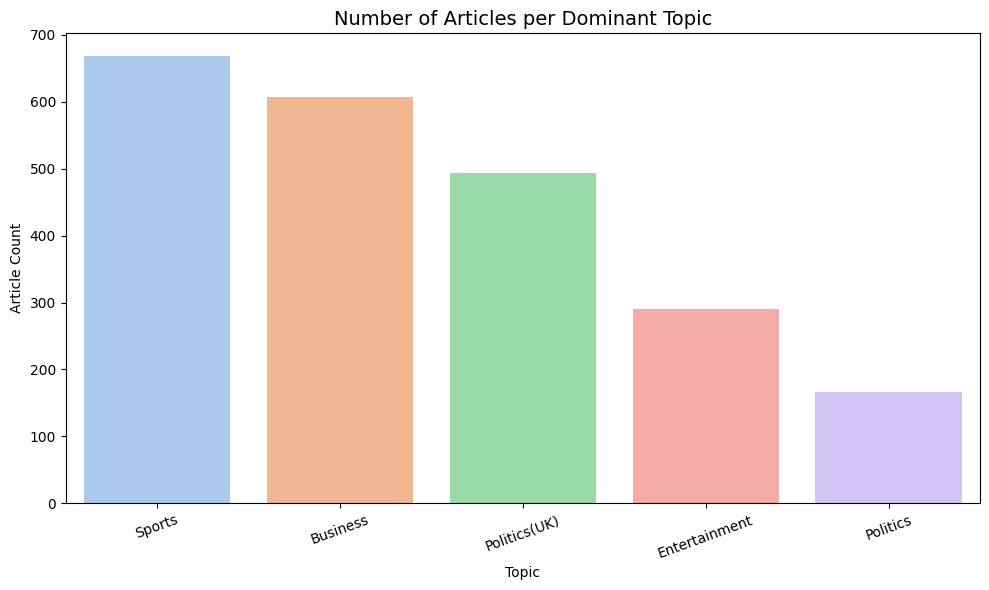

In [3]:
# Step 2: Preprocess text
def preprocess(text):
    return [word for word in simple_preprocess(text, deacc=True) 
            if word not in STOPWORDS and len(word) > 2]

texts = df['text'].map(preprocess)

# Step 3: Build bigrams
bigram = Phrases(texts, min_count=5, threshold=100)
bigram_mod = Phraser(bigram)
texts = [bigram_mod[doc] for doc in texts]

# Step 4: Create dictionary and corpus
id2word = corpora.Dictionary(texts)
corpus = [id2word.doc2bow(text) for text in texts]

# Step 5: Train LDA model
lda_model = LdaModel(corpus=corpus,id2word=id2word,num_topics=5,random_state=100,passes=10,alpha='auto',per_word_topics=True)

# Step 6: Map topic numbers to labels
topic_labels = {0: "Business",1: "Sports",2: "Politics",3: "Politics(UK)",4: "Entertainment"}

# Step 7: Assign dominant topic to each document
def format_topics(ldamodel, corpus, texts):
    results = []
    for i, row in enumerate(ldamodel[corpus]):
        row = sorted(row[0], key=lambda x: (x[1]), reverse=True)
        topic_num, prop_topic = row[0]
        keywords = ", ".join([word for word, _ in ldamodel.show_topic(topic_num)])
        results.append((i, int(topic_num), round(prop_topic, 4), keywords, texts[i]))
    return pd.DataFrame(results, columns=['Doc_ID', 'Dominant_Topic', 'Perc_Contribution', 'Keywords', 'Text'])

df_topics = format_topics(lda_model, corpus, df['text'])
df_topics['Topic_Label'] = df_topics['Dominant_Topic'].map(topic_labels)

# Step 8: Bar chart of topic distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df_topics, x='Topic_Label', palette='pastel',
              order=df_topics['Topic_Label'].value_counts().index)
plt.title('Number of Articles per Dominant Topic', fontsize=14)
plt.xlabel('Topic')
plt.ylabel('Article Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

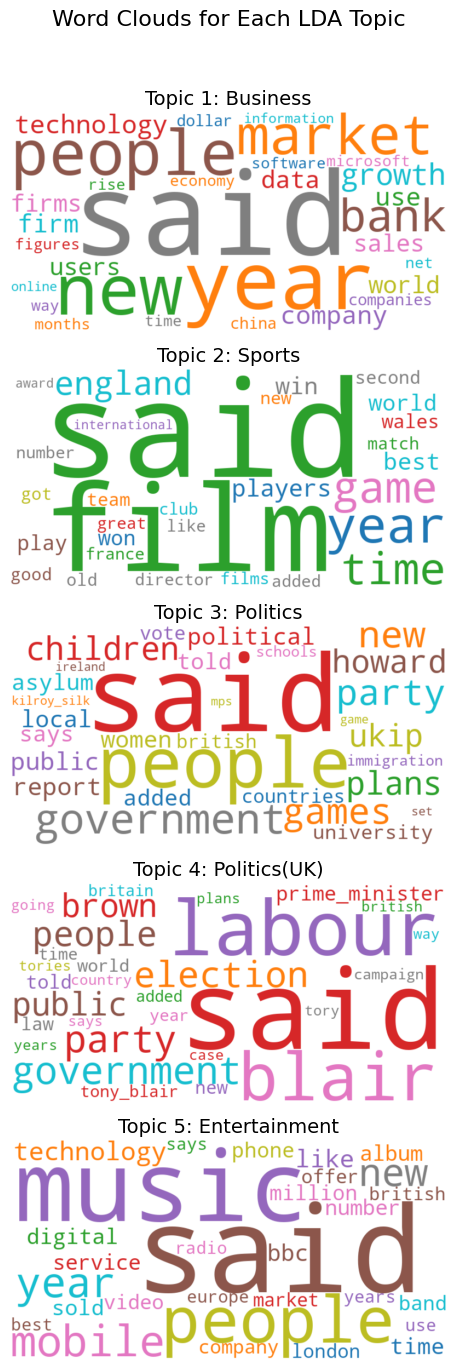

In [4]:
from wordcloud import WordCloud

# Step 10: Generate Word Clouds for each topic
cols = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]  # Color palette

fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True, sharey=True)
for i, ax in enumerate(axes):
    topic_words = dict(lda_model.show_topic(i, 30))
    wordcloud = WordCloud(width=800, height=400,background_color='white',colormap='tab10',prefer_horizontal=1.0).generate_from_frequencies(topic_words)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Topic {i+1}: {topic_labels[i]}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Word Clouds for Each LDA Topic", fontsize=16, y=1.05)
plt.show()

C:\Users\Madhu\anaconda3\envs\FDS\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.016s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.002953
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.827236
[t-SNE] KL divergence after 500 iterations: 0.464718


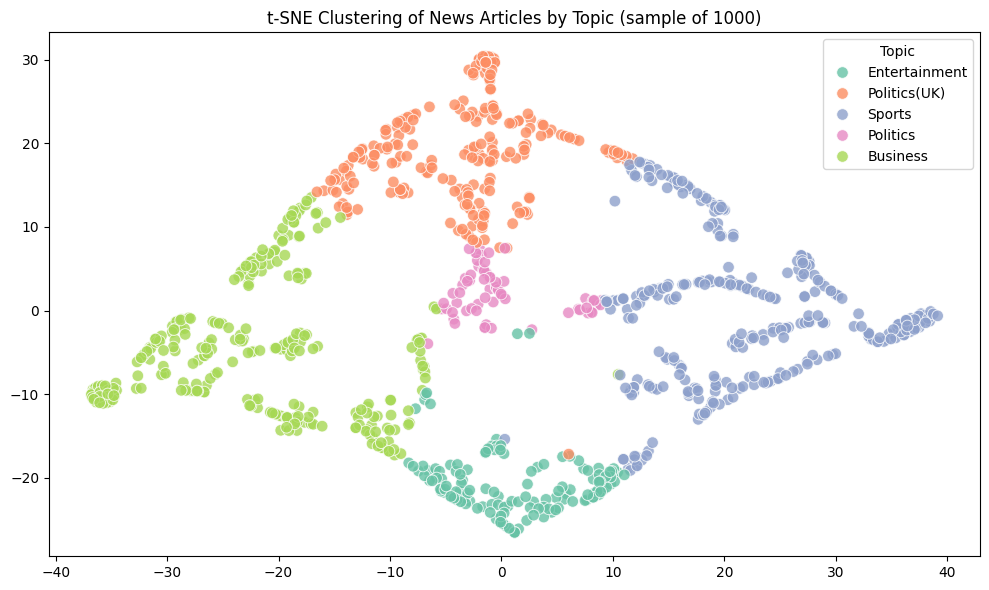

In [7]:
# Step 9: t-SNE visualization
# Extract topic distributions for each document
topic_weights = []
for i, row_list in enumerate(lda_model[corpus]):
    topic_dist = [0] * lda_model.num_topics
    for topic_num, weight in row_list[0]:
        topic_dist[topic_num] = weight
    topic_weights.append(topic_dist)

# Reduce size for faster t-SNE
sample_size = 1000
topic_weights_subset = topic_weights[:sample_size]
labels_subset = df_topics['Topic_Label'].values[:sample_size]

# Apply t-SNE
tsne_model = TSNE(n_components=2,perplexity=30,n_iter=500,init='pca',learning_rate='auto',random_state=42,verbose=1)

import numpy as np
topic_weights_subset = np.array(topic_weights_subset)
tsne_result = tsne_model.fit_transform(topic_weights_subset)


# Create DataFrame for t-SNE results
tsne_df = pd.DataFrame(tsne_result, columns=['x', 'y'])
tsne_df['Topic'] = labels_subset

# Plot t-SNE results
plt.figure(figsize=(10,6))
sns.scatterplot(x='x', y='y', hue='Topic', data=tsne_df, palette='Set2', s=70, alpha=0.8)
plt.title('t-SNE Clustering of News Articles by Topic (sample of 1000)')
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Topic', loc='best')
plt.tight_layout()
plt.show()

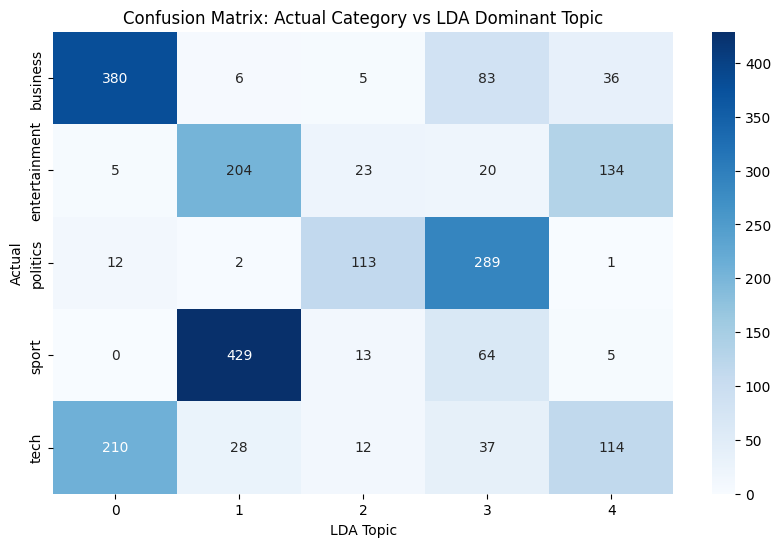

Topic 0: said, year, new, people, market
Topic 1: said, film, year, game, time
Topic 2: said, people, government, new, party
Topic 3: said, labour, blair, government, party
Topic 4: said, music, people, mobile, year


In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Add original category (ground truth) to df_topics
df_topics['Actual_Category'] = df['category']

# === STEP 1: Create confusion matrix ===
conf_matrix = pd.crosstab(df_topics['Actual_Category'], df_topics['Dominant_Topic'],
                          rownames=['Actual'], colnames=['LDA Topic'])

# === STEP 2: Auto-label topics using top 5 keywords ===
auto_labels = {}
for topic_id in range(lda_model.num_topics):
    top_words = lda_model.show_topic(topic_id, topn=5)
    label = ", ".join([word for word, _ in top_words])
    auto_labels[topic_id] = label

# Add these labels to the dataframe
df_topics['Auto_Topic_Label'] = df_topics['Dominant_Topic'].map(auto_labels)

# === STEP 3: Classification Report ===
# Convert dominant topic numbers to string labels for consistent comparison
y_true = df_topics['Actual_Category']
y_pred = df_topics['Auto_Topic_Label']  # now strings like "game, play, win..."

report = classification_report(y_true, y_pred, zero_division=0, output_dict=True)


# === Optional: Print nicely ===
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Actual Category vs LDA Dominant Topic")
plt.show()

# View auto-generated labels
for topic_id, label in auto_labels.items():
    print(f"Topic {topic_id}: {label}")

In [6]:
topic_labels = {0: "Business",1: "Sports",2: "Politics",3: "Politics(UK)",4: "Entertainment"}

In [8]:
# Display top keywords and their weights per topic
for topic_id in range(lda_model.num_topics):
    print(f"\n=== Topic {topic_id} ({topic_labels.get(topic_id, 'No Label')}) ===")
    for word, weight in lda_model.show_topic(topic_id, topn=10):
        print(f"{word:<15} {weight:.4f}")



=== Topic 0 (Business) ===
said            0.0174
year            0.0069
new             0.0053
people          0.0049
market          0.0036
bank            0.0032
growth          0.0032
technology      0.0032
firm            0.0032
company         0.0031

=== Topic 1 (Sports) ===
said            0.0099
film            0.0077
year            0.0071
game            0.0053
time            0.0052
england         0.0052
players         0.0051
best            0.0049
win             0.0049
world           0.0044

=== Topic 2 (Politics) ===
said            0.0235
people          0.0076
government      0.0052
new             0.0040
party           0.0038
games           0.0038
plans           0.0029
children        0.0029
howard          0.0028
ukip            0.0027

=== Topic 3 (Politics(UK)) ===
said            0.0213
labour          0.0080
blair           0.0059
government      0.0051
party           0.0050
election        0.0046
people          0.0042
public          0.0037
brown       